<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load libraries

In [9]:
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, \
StackingRegressor
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Create initial dataframe to work with
Download tickers for the USD value of the last 5 years

In [10]:
ticker_symbol = "DX-Y.NYB"
ticker = yf.Ticker(ticker_symbol)
df = ticker.history(period="5y").reset_index(drop=False)
df = df.drop(columns=['Volume', 'Dividends', 'Stock Splits'])
df

,Date,Open,High,Low,Close
0,2020-11-05 00:00:00-05:00,93.339996,93.550003,92.489998,92.529999
1,2020-11-06 00:00:00-05:00,92.570000,92.820000,92.180000,92.230003
2,2020-11-09 00:00:00-05:00,92.239998,92.959999,92.129997,92.730003
3,2020-11-10 00:00:00-05:00,92.760002,92.970001,92.599998,92.750000
4,2020-11-11 00:00:00-05:00,92.699997,93.209999,92.610001,93.040001
...,...,...,...,...,...
1252,2025-10-29 00:00:00-04:00,98.739998,99.360001,98.620003,99.220001
1253,2025-10-30 00:00:00-04:00,99.139999,99.720001,98.919998,99.529999
1254,2025-10-31 00:00:00-04:00,99.489998,99.839996,99.419998,99.800003
1255,2025-11-03 00:00:00-05:00,99.750000,99.989998,99.709999,99.870003


In [11]:
dates = df['Date']
rest = df.drop(columns=['Date'])
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates, y=df['Open'], name='Open',
              line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x=dates, y=df['Low'], name='Low',
              line=dict(color='royalblue', width=4, dash='dash')))
fig.add_trace(go.Scatter(x=dates, y=df['High'], name='High',
              line=dict(color='lightsteelblue', width=4, dash='dot')))
fig.add_trace(go.Scatter(x=dates, y=df['Close'], name='Close',
              line=dict(color='limegreen', width=4, dash='dashdot')))
fig.update_layout(autosize=False, width=1200, height=500)
fig.show()

#Q2 - Is the time series static?
The USD time series is not a static/stationary time series, due to the fact that its previous values cannot be used to safely predict its future values.

# Q3 - Training a Regressor on non-static/non-stationary timeseries
Having a Regressor trained on non-stationary timeseries is problematic due to the fact that the model cannot be trusted to predict future values based on the previous values. Should the timeseries be stationary, a Regressor could be trusted to predict values and even be used in anomaly detection, but for non-stationary timeseries, this is not the case.

# Q4 - USD trends between June and July, 2025
Possible factors in USD's value are tensions due to the tariffs imposed by the US Government, along with a truce between Israel and Iran. What is also notable is the 3% rise near the end of July, where the dollar recovered from a low value of 97 to 100. 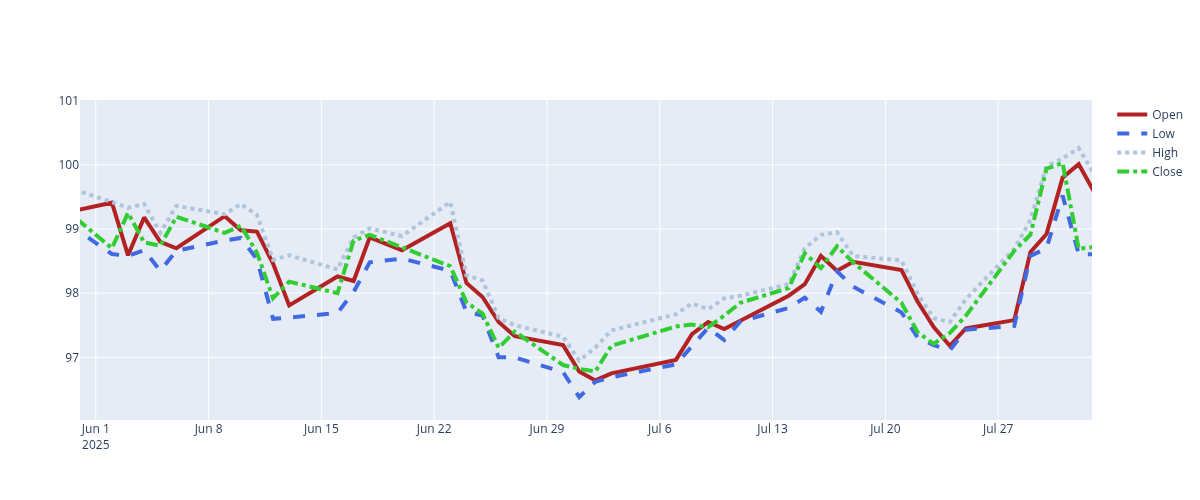

# Q5 - Is the value of Close predictable?
It is possible to predict the next day's Close value based on a day's Open, High, Low and Close values, with a certain accuracy. To do so, we must train a model which will try to approximate the market's behavior, thus allowing us to predict future values.

# Q6 - To split data in train-test, or not to split?
Splitting the data in train-test is a mandatory step towards training and assessing an ML model. However, we only need to split the data in past and future parts, not in a completely random fashion.

# Q7 - Createa dataset with Dataframes

In [32]:
date_df = df.copy()
date_test = "2024-01-01"
date_df['Date'] = pd.to_datetime(df['Date'])
date_df = date_df.set_index(date_df['Date'])
date_df = date_df.sort_index()
train_df = date_df["2020-01-01":"2024-01-01"]
test_df = date_df[date_test:]
train_df = train_df.drop(columns=['Date'])
test_df = test_df.drop(columns=['Date'])

# Q8 - Helper function to get a dataset in a format used for training a model

Δημιουργήστε συνάρτηση που θα παίρνει ως όρισμα ένα dataframe (είτε του train είτε του test), καθώς και μια παράμετρο  και θα επιστρέφει 2 numpy arrays: Inputs (x) και Targets (y), όπου x τα timeframes και y η τιμή close της επόμενης ημέρες. Τα timeframe είναι ένα σύνολο  διαδοχικών γραμμών. Για παράδειγμα αν N=3, τότε τα timeframes θα ήταν πίνακες 3x4, όπου 3 οι γραμμές και 4 τα χαρακτηριστικά open, high, low, close. Για N μέγεθος, το 1ο Timeframe θα περιλαμβάνει τις γραμμές x0:[0, N-1], το 2ο τις x1:[1:N], το 3ο x2:[2,N+1], κλπ. Για τα targets, το y0 θα ήταν το αντίστοιχο cN το y1 το cN+1, κλπ. Για τα Targets μπορείτε να χρησιμοποιήσετε την εντολή shift της pandas.

In [13]:
def convert(df, N):
  target = df['Close']#.shift(periods=N)
  X = []
  Y = []
  # print('getting first pos\n', df.iloc[0:N, :])
  # print('getting target\n', df.iloc[N, -1])
  # print('getting 0 target:', target[N])
  for i in range(len(df)-N):
    x = df.iloc[i:i+N, :]
    y = target[i+N]
    x = np.array(x)
    x = x.flatten()
    X.append(x)
    Y.append(y)
  X = np.array(X)
  Y = np.array(Y)
  # print(X[0], Y[0])
  # print(X.shape, Y.shape)
  return X, Y

# convert(test_df, 3)

# Q9 - The effect of N
In order to predict next day's Close value, a small value of N might be more preferable, since the model will learn to predict more easily based on shorter periods of, where smaller deviations of the target value appear.

N should have a larger value if we aimed to predict the Close value on a larger time frame, since it would help the model make more accurate predictions without focusing on small-scale details.

#Q10 - Creating the dataset using numpy

In [14]:
N = 5
x_train, y_train = convert(train_df, N)
x_test, y_test = convert(test_df, N)
print(x_train.shape, y_train.shape)

(787, 20) (787,)


/tmp/ipython-input-1974869031.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



#Q11 - Train various models, then compare

In [23]:
scores = {}
models = {'Linear': LinearRegression(),
          'Random Forest': RandomForestRegressor(random_state=0),
          'Bagging': BaggingRegressor(LinearRegression(), random_state=0),
          'XGB': xgb.XGBRegressor(n_jobs=1),
          'Stacking': StackingRegressor([('linear', LinearRegression()),
                              ('decision_tree', DecisionTreeRegressor())]) }

for model_name, model in models.items():
  model.fit(x_train, y_train)
  preds_train = model.predict(x_train)
  preds_test = model.predict(x_test)
  scores[model_name] = [mean_absolute_error(y_train, preds_train),
                    mean_absolute_error(y_test, preds_test)]

model_names = list(scores.keys())
train_scores = [v[0] for v in scores.values()]
test_scores = [v[1] for v in scores.values()]

fig = go.Figure(data=[
    go.Bar(name='Train MAE', x = model_names, y=train_scores, marker_color='blue'),
    go.Bar(name='Test MAE', x = model_names, y=test_scores, marker_color='green')
])

fig.update_layout(
    barmode='group',
    title='Regressor Mean Absolute Errors',
    xaxis_title='Regressor',
    yaxis_title='MAE'
)

fig.show()

### Explaining how each Regression model works
#### Linear Regression
Linear Regression models aim to fit coefficients as many as the features of our dataset in order to minimize the residual sum of squares between the actual values and the predicted values (predicted by linear approximation).
#### Random Forest Regressor
A Random Forest Regression model leverages multiple Decision Trees using different subsets of the data and features, and then takes an average of the predictions to produce a predicted value for a given input
#### Bagging Regressor
Bagging Regression models fit multiple base models (in our case, Linear Regression models) on random subsets of our original dataset, and then take the average of the individual predictions to form a final prediction.
#### XGBoost Regressor
XGBoost relies on Decision Trees, training an ensemble of them on different subsets of the dataset. What XGBoost does differently than RandomForest is that the trees grow sequentially instead of in parallel, where each tree learns from the mistakes of the previous tree. Similarly, the outcome is based on the average of the decision trees.
#### Stacking Regressor
Stacking Regression models work by stacking the output of individual estimators (in our case, a Linaer Regression model and a Decision Tree) and use a regressor to compute the final prediction. Stacking allows us to use the strength of each individual estimator by using their output as input in a second-layer which plays the role of the final estimator, combining the predictions of the base estimators to make predictions.

# Q12 - Improving the accuracy by enhancing the dataset

#### a) Add month and day features

In [16]:
months_df = date_df['Date'].dt.month
days_df = date_df['Date'].dt.day
train_lr_df = train_df.copy()
test_lr_df = test_df.copy()
train_lr_df['Month'] = months_df["2020-01-01":"2024-01-01"]
train_lr_df['Day'] = days_df["2020-01-01":"2024-01-01"]
test_lr_df['Month'] = months_df["2024-01-01":]
test_lr_df['Day'] = days_df["2024-01-01":]

#### Why would discrete month and day columns help the models make better predictions?
Having a months column allows a model to make better predictions by introducing more information about the reason behind fluctuations in the USD value. Then, the model can take that information into account and make use of it in its predictions on unknown data.

#### b) Apply the Log Returns formula: yₜ=ln(y_t+1)-ln(y_t)

In [17]:
columns = ['Open', 'High', 'Low', 'Close']

for col in columns:
  # solution found here: https://stackoverflow.com/a/39419036
  train_lr_df[col+'_LR'] = np.log(train_lr_df[col]/train_lr_df[col].shift(1))
  train_lr_df.loc[train_lr_df.index[0], col+'_LR'] = 0 # change from NaN to 0 :)
  test_lr_df[col+'_LR'] = np.log(test_lr_df[col]/test_lr_df[col].shift(1))
  test_lr_df.loc[test_lr_df.index[0], col+'_LR'] = 0
train_lr_df
# Troubleshoot code below
# col = 'Open'
# # solution found here: https://stackoverflow.com/a/39419036
# res = np.log(train_lr_df[col]/train_lr_df[col].shift(1))
# res.iloc[[0]] = 0 # change from NaN to 0 :)


,Open,High,Low,Close,Month,Day,Open_LR,High_LR,Low_LR,Close_LR
Date,,,,,,,,,,
2020-11-05 00:00:00-05:00,93.339996,93.550003,92.489998,92.529999,11,5,0.000000,0.000000,0.000000,0.000000
2020-11-06 00:00:00-05:00,92.570000,92.820000,92.180000,92.230003,11,6,-0.008284,-0.007834,-0.003357,-0.003247
2020-11-09 00:00:00-05:00,92.239998,92.959999,92.129997,92.730003,11,9,-0.003571,0.001507,-0.000543,0.005407
2020-11-10 00:00:00-05:00,92.760002,92.970001,92.599998,92.750000,11,10,0.005622,0.000108,0.005089,0.000216
2020-11-11 00:00:00-05:00,92.699997,93.209999,92.610001,93.040001,11,11,-0.000647,0.002578,0.000108,0.003122
...,...,...,...,...,...,...,...,...,...,...
2023-12-22 00:00:00-05:00,101.760002,101.900002,101.430000,101.699997,12,22,-0.006172,-0.005383,-0.003052,-0.001376
2023-12-26 00:00:00-05:00,101.650002,101.769997,101.449997,101.470001,12,26,-0.001082,-0.001277,0.000197,-0.002264
2023-12-27 00:00:00-05:00,101.550003,101.570000,100.830002,100.989998,12,27,-0.000984,-0.001967,-0.006130,-0.004742


In [18]:
cols = train_lr_df.columns
cols = ["Open",	"High", "Low", "Close",
        "Open_LR", "High_LR", "Low_LR",	"Close_LR"]
cols_per_row = 4
rows = (len(cols) + cols_per_row - 1) // cols_per_row  # ceiling division

fig = make_subplots(rows=rows, cols=cols_per_row, subplot_titles=cols)

for i, col in enumerate(cols):
    r, c = divmod(i, cols_per_row)
    fig.add_trace(
        go.Histogram(x=train_lr_df[col], name=col, nbinsx=30),
        row=r + 1, col=c + 1
    )

fig.update_layout(
    height=300 * rows,
    width=1200,
    title_text='Histograms of DataFrame Columns',
    showlegend=False
)

fig.show()



#### c) How could this improve a model's performance?
These alterations center the values around 0. This allows the model to detect patterns more easily, as it does not rely on actual data values but rather on the logarithmic difference between the previous day and today's value, thus resulting in a more robust predictor.

#### d) What does $c_{t+1} = 0.01$ mean?
If $c_{t+1}=0.01$, that would mean that the logarithmic change from the value of t to the value of t+1 is +1% for Close.

If cₜ=0.95\$, and $c_{t+1} = 0.01$, then $c_{t+1}=|e^{ln(1/100)}-1|=0.99$.

#### e) Retrain the models using the new dataset

In [52]:
N = 5
def convert_LR(df, N,
               exclude=["Open",	"High", "Low", "Close"]):
  """ Convert a pandas dataframe to a numpy dataset
  using the logarithmic returns columns only! """
  target = df['Close_LR']#.shift(periods=N)
  X = []
  Y = []
  df = df.drop(columns=exclude)

  for i in range(len(df)-N):
    x = df.iloc[i:i+N, :]
    y = target.iloc[i+N]
    x = np.array(x)
    x = x.flatten()
    X.append(x)
    Y.append(y)
  X = np.array(X)
  Y = np.array(Y)
  return X, Y
x_train, y_train = convert_LR(train_lr_df, N)
x_test, y_test = convert_LR(test_lr_df, N)
scores_LR = {}
models_LR = {'Linear': LinearRegression(),
          'Random Forest': RandomForestRegressor(random_state=0),
          'Bagging': BaggingRegressor(LinearRegression(), random_state=0),
          'XGB': xgb.XGBRegressor(n_jobs=1),
          'Stacking': StackingRegressor([('linear', LinearRegression()),
                              ('decision_tree', DecisionTreeRegressor())]) }

for model_name, model in models_LR.items():
  model.fit(x_train, y_train)
  preds_train = model.predict(x_train)
  preds_test = model.predict(x_test)
  scores_LR[model_name] = [mean_absolute_error(y_train, preds_train),
                    mean_absolute_error(y_test, preds_test)]

model_names = list(scores.keys())
train_scores = [v[0] for v in scores_LR.values()]
test_scores = [v[1] for v in scores_LR.values()]

fig = go.Figure(data=[
    go.Bar(name='Train MAE', x = model_names, y=train_scores, marker_color='blue'),
    go.Bar(name='Test MAE', x = model_names, y=test_scores, marker_color='green')
])

fig.update_layout(
    barmode='group',
    title='Regressor Mean Absolute Errors',
    xaxis_title='Regressor',
    yaxis_title='MAE'
)

fig.show()

#### How come the MAE is so small?
As seen in the bar chart above, the Mean Absolute Errors are two orders of magnitude smaller than the errors observed in the previous training session, where the data were not pre-processed. This highlights how much of an impact pre-processing has on the models' ability to learn the hidden patterns in the data, and make correct predictions, while being less prone to value fluctuations.

# Q13 - Line plot of predictions against true values
It seems like the best accuracy is achieved by the XGB Regressor - even though the smallest MAE is observed in the Stacking Regressor - so we'll plot the XGB model predictions against the true values.

In [60]:
r = models_LR['XGB'].predict(x_test)
seed_price = test_lr_df['Close'].iloc[N-1]
log_seed = np.log(seed_price)
log_prices_pred = log_seed + np.cumsum(r)
prices_pred = np.exp(log_prices_pred)
prices_true = test_lr_df.loc[date_test:, 'Close'].values
R = np.exp(r) - 1
R_true = np.exp(y_test) - 1
fig = go.Figure()
fig.add_trace(go.Scatter(x=date_df['Date'][date_test:], y=prices_pred, name='Predicted',
              line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x=date_df['Date'][date_test:], y=prices_true, name='True',
              line=dict(color='royalblue', width=4, dash='dash')))
fig.update_layout(autosize=True,
                  title='Predicted vs True Close prices',)
fig.show()